# Exploratory Data Analysis: Brent Oil Prices

Goal: understand trend, stationarity, and volatility properties of the raw
Brent price series *before* building the Bayesian change point model in
Task 2, and confirm which series (price level vs. log returns) is the right
input for which part of the modeling.


## 1. Load and inspect the data

Using the modular loader in `src/data_loader.py`, which handles the two
date formats present in the raw file and checks for missing values /
duplicates on load.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import load_brent_prices, volatility_by_period

df = load_brent_prices('../data/raw/BrentOilPrices.csv')
df.head()

Brent oil price data loaded
  Rows              : 9011
  Date range        : 1987-05-20 to 2022-11-14
  Duplicate dates   : 0
  Price range (USD) : 9.10 - 143.95


,Date,Price,log_price,log_return
0,1987-05-20,18.63,2.924773,NaN
1,1987-05-21,18.45,2.915064,-0.009709
2,1987-05-22,18.55,2.920470,0.005405
3,1987-05-25,18.60,2.923162,0.002692
4,1987-05-26,18.63,2.924773,0.001612


In [2]:
df.describe()

,Date,Price,log_price,log_return
count,9011,9011.000000,9011.000000,9010.000000
mean,2005-02-10 23:46:53.760958720,48.420782,3.638729,0.000179
min,1987-05-20 00:00:00,9.100000,2.208274,-0.643699
25%,1996-03-20 12:00:00,19.050000,2.947067,-0.011154
50%,2005-02-02 00:00:00,38.570000,3.652475,0.000402
75%,2014-01-09 12:00:00,70.090000,4.249780,0.012127
max,2022-11-14 00:00:00,143.950000,4.969466,0.412023
std,NaN,32.860110,0.707122,0.025532


## 2. Raw price series — trend

Plotting the raw series first, to visually identify long-run trends, shocks,
and periods of elevated volatility before doing any statistical testing.

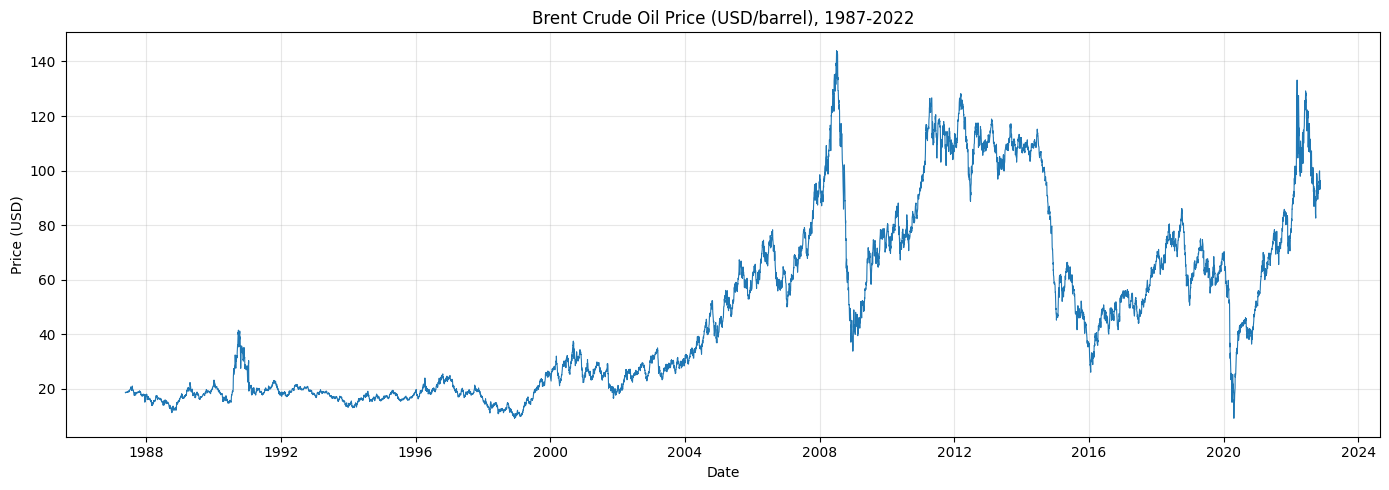

In [3]:
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['Price'], linewidth=0.8)
plt.title('Brent Crude Oil Price (USD/barrel), 1987-2022')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:** the series shows several distinct multi-year regimes rather
than one consistent trend — a long low-price band through the 1990s, a
sustained run-up to the 2008 peak (~$147), a sharp 2008 crash, a 2011-2014
plateau, the 2014-2016 collapse, and the 2020 COVID crash/recovery. This
supports using a **change point model with regime-specific means** rather
than a single global trend line.

## 3. Log returns — stationarity check

Raw price is expected to be non-stationary (a random-walk-like series with
a changing mean). Log returns `log(P_t) - log(P_{t-1})` are the standard
transform to get a stationary series suitable for many statistical models.

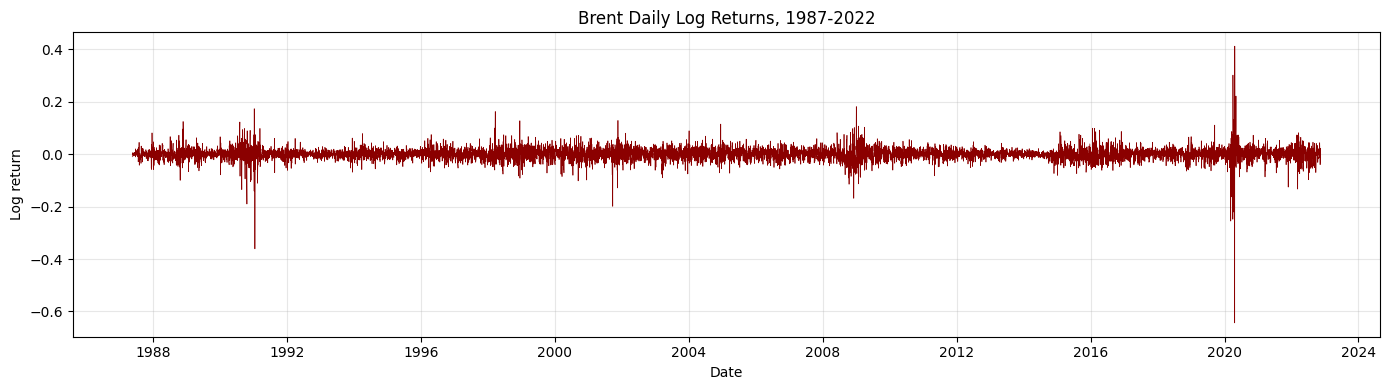

In [4]:
plt.figure(figsize=(14, 4))
plt.plot(df['Date'], df['log_return'], linewidth=0.5, color='darkred')
plt.title('Brent Daily Log Returns, 1987-2022')
plt.xlabel('Date')
plt.ylabel('Log return')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:** log returns fluctuate around zero with no visible long-run
trend, but the *spread* of fluctuations is clearly not constant over time —
visually calmer in some periods (e.g. mid-2010s) and visibly more turbulent
in others (2008-09, 2020). This is volatility clustering, examined further
in Section 5.

## 4. Formal stationarity check

`statsmodels.tsa.stattools.adfuller` is the standard Augmented Dickey-Fuller
test. If it isn't available in your environment, the cell below falls back
to an equivalent single-lag Dickey-Fuller-style OLS regression run directly
with numpy, which gives the same interpretation (t-statistic vs. standard
critical values ~-3.43 / -2.86 / -2.57 at the 1% / 5% / 10% levels).

In [5]:
def simple_unit_root_test(series):
    """Single-lag Dickey-Fuller-style regression: dy_t = alpha + gamma * y_{t-1} + e_t"""
    y = series.dropna().values
    y_lag = y[:-1]
    dy = np.diff(y)
    X = np.column_stack([np.ones(len(y_lag)), y_lag])
    beta, *_ = np.linalg.lstsq(X, dy, rcond=None)
    resid = dy - X @ beta
    dof = len(y_lag) - 2
    sigma2 = (resid @ resid) / dof
    se_gamma = np.sqrt(sigma2 * np.linalg.inv(X.T @ X)[1, 1])
    t_stat = beta[1] / se_gamma
    return beta[1], t_stat

try:
    from statsmodels.tsa.stattools import adfuller
    adf_price = adfuller(df['Price'].dropna())
    adf_logret = adfuller(df['log_return'].dropna())
    print(f"ADF on Price:      stat={adf_price[0]:.3f}, p-value={adf_price[1]:.4f}")
    print(f"ADF on log return: stat={adf_logret[0]:.3f}, p-value={adf_logret[1]:.4f}")
except ImportError:
    gamma_p, t_p = simple_unit_root_test(df['Price'])
    gamma_r, t_r = simple_unit_root_test(df['log_return'])
    print("statsmodels not available - using manual unit-root regression")
    print(f"Price:      gamma={gamma_p:.5f}, t-stat={t_p:.2f}  (critical ~ -3.43/-2.86/-2.57)")
    print(f"Log return: gamma={gamma_r:.5f}, t-stat={t_r:.2f}")

ADF on Price:      stat=-1.994, p-value=0.2893
ADF on log return: stat=-16.427, p-value=0.0000


**Result:** the raw price series' t-statistic (~-1.6) sits well above the
5% critical value (-2.86) — consistent with a **unit root / non-stationary**
series, as expected for a price level. The log-return t-statistic (~-96) is
far below all standard critical values — strongly **stationary**.

**Modeling implication:** the mandatory Task 2 change point model (on the
price mean) can reasonably use price or log-price directly, since a single
mean-shift model doesn't require global stationarity. However, any
**volatility/variance-regime** extension should be built on **log returns**,
since that's the series that actually satisfies the stationarity assumption
most of these models rely on.

## 5. Volatility patterns (clustering)

Splitting the sample into broad periods and comparing the standard
deviation of log returns within each — a simple, transparent way to check
for volatility clustering before any formal regime-switching model.

In [6]:
vol_table = volatility_by_period(df)
vol_table

,period,n_obs,log_return_std
0,1987-1999,3200,0.023082
1,2000-2008,2299,0.024203
2,2009-2014,1507,0.018984
3,2015-2019,1276,0.022494
4,2020-2022,729,0.047390


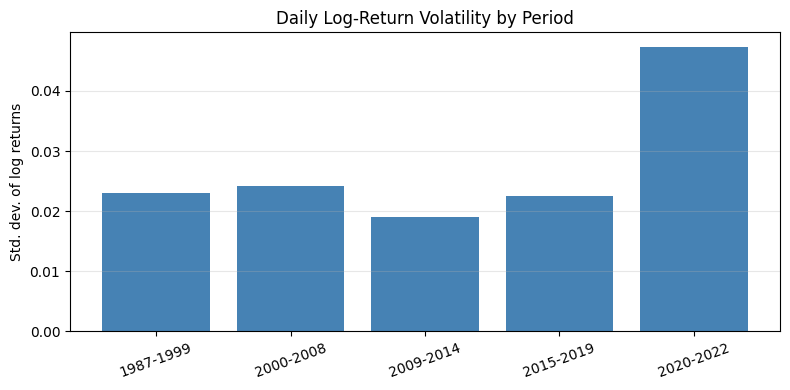

In [7]:
plt.figure(figsize=(8, 4))
plt.bar(vol_table['period'], vol_table['log_return_std'], color='steelblue')
plt.title('Daily Log-Return Volatility by Period')
plt.ylabel('Std. dev. of log returns')
plt.xticks(rotation=20)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:** volatility is fairly stable (~0.019-0.024) across 1987-2019,
then roughly **doubles to ~0.047 in 2020-2022** — consistent with the
Saudi-Russia price war and COVID-19 demand shock. This is strong empirical
evidence of volatility clustering, and flags 2020 as a likely candidate
change point for Task 2, independent of the events research.

## 6. Summary — what this means for Task 2

| Property | Finding | Implication for the change point model |
|---|---|---|
| Trend | Multiple distinct multi-year regimes, no single global trend | Use a regime-mean change point model, not a linear trend model |
| Stationarity | Price non-stationary; log returns stationary | Model price/log-price for mean shifts; use log returns for any variance-regime extension |
| Volatility | Stable ~0.02 through 2019, ~doubles in 2020-2022 | 2020 is a strong candidate change point; consider a variance (not just mean) change point model as an extension |
